# Фінальний проєкт: бінарна класифікація

**Мета:** побудувати модель для прогнозування цільової змінної `y` та сформувати файл прогнозів для змагання.

**Метрика:** `Balanced Accuracy`, оскільки класи у навчальному наборі незбалансовані.

**Дані:**
- `final_proj_data.csv` — навчальний набір;
- `final_proj_test.csv` — тестовий набір змагання;
- `final_proj_sample_submission.csv` — шаблон submission.

У роботі виконано:
1. первинний аналіз даних;
2. дослідження пропусків і кардинальності категорій;
3. побудову ML-конвеєра;
4. порівняння Logistic Regression, PCA/SVD та LinearSVC;
5. побудову CatBoostClassifier;
6. вибір фінальної моделі та формування submission.

## 1. Імпорт бібліотек і налаштування

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder
from sklearn.svm import LinearSVC

from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

## 2. Завантаження даних

In [2]:
#from kagglehub import KaggleDatasetAdapter

DATA_DIR = "/kaggle/input/competitions/ml-fundamentals-and-applications-2025-07-08"

train_path = os.path.join(DATA_DIR, "final_proj_data.csv")
test_path = os.path.join(DATA_DIR, "final_proj_test.csv")
sample_path = os.path.join(DATA_DIR, "final_proj_sample_submission.csv")

train_df = pd.read_csv(train_path)
competition_test_df = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_path)

print("Train shape:", train_df.shape)
print("Competition test shape:", competition_test_df.shape)
print("Sample submission shape:", sample_submission.shape)

Train shape: (10000, 231)
Competition test shape: (2500, 230)
Sample submission shape: (2500, 2)


In [3]:
display(train_df.head())
display(sample_submission.head())

,Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8,Var9,Var10,...,Var222,Var223,Var224,Var225,Var226,Var227,Var228,Var229,Var230,y
0,NaN,NaN,NaN,NaN,NaN,812.0,14.0,NaN,NaN,NaN,...,catzS2D,jySVZNlOJy,NaN,xG3x,Aoh3,ZI9m,ib5G6X1eUxUn6,mj86,NaN,0
1,NaN,NaN,NaN,NaN,NaN,2688.0,7.0,NaN,NaN,NaN,...,i06ocsg,LM8l689qOp,NaN,kG3k,WqMG,RAYp,55YFVY9,mj86,NaN,0
2,NaN,NaN,NaN,NaN,NaN,1015.0,14.0,NaN,NaN,NaN,...,P6pu4Vl,LM8l689qOp,NaN,kG3k,Aoh3,ZI9m,R4y5gQQWY8OodqDV,am7c,NaN,0
3,NaN,NaN,NaN,NaN,NaN,168.0,0.0,NaN,NaN,NaN,...,BNrD3Yd,LM8l689qOp,NaN,NaN,FSa2,RAYp,F2FyR07IdsN7I,NaN,NaN,0
4,NaN,NaN,NaN,NaN,NaN,14.0,0.0,NaN,NaN,NaN,...,3B1QowC,LM8l689qOp,NaN,NaN,WqMG,RAYp,F2FyR07IdsN7I,NaN,NaN,0


,index,y
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


## 3. Первинна перевірка даних

In [4]:
print("Кількість дублікатів:", train_df.duplicated().sum())
print("Загальна кількість пропусків:", train_df.isna().sum().sum())

train_df.info()

Кількість дублікатів: 0
Загальна кількість пропусків: 1603449
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 231 entries, Var1 to y
dtypes: float64(191), int64(2), object(38)
memory usage: 17.6+ MB


In [5]:
X = train_df.drop(columns="y")
y = train_df["y"]

numeric_columns = X.select_dtypes(include="number").columns.tolist()
categorical_columns = X.select_dtypes(exclude="number").columns.tolist()

print("Кількість об'єктів:", len(train_df))
print("Кількість ознак:", X.shape[1])
print("Числових ознак:", len(numeric_columns))
print("Категоріальних ознак:", len(categorical_columns))

Кількість об'єктів: 10000
Кількість ознак: 230
Числових ознак: 192
Категоріальних ознак: 38


### Висновок

Набір містить 10 000 навчальних об’єктів і 230 ознак. Ознаки поділено на числові та категоріальні відповідно до типів даних. Цільова змінна `y` не використовується під час попередньої обробки ознак.

## 4. Аналіз цільової змінної

,count,share
y,,
0,8695,0.8695
1,1305,0.1305


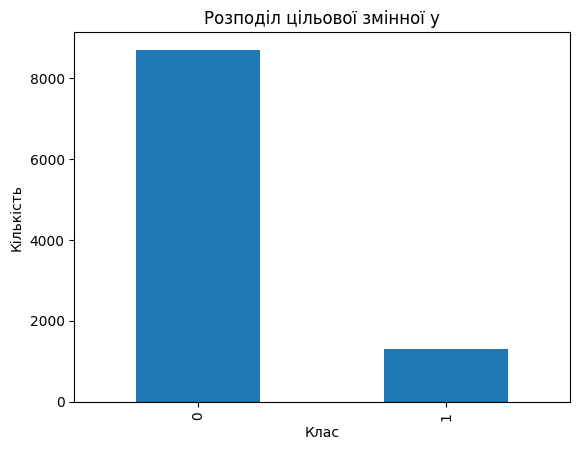

In [6]:
target_counts = y.value_counts().sort_index()
target_share = y.value_counts(normalize=True).sort_index()

target_summary = pd.DataFrame({
    "count": target_counts,
    "share": target_share
})

display(target_summary)

target_counts.plot(kind="bar", title="Розподіл цільової змінної y")
plt.xlabel("Клас")
plt.ylabel("Кількість")
plt.show()

### Висновок

Клас `0` суттєво переважає клас `1`. Звичайна accuracy могла б створити хибне враження високої якості, тому основною метрикою обрано **Balanced Accuracy**. Для лінійних моделей використовується `class_weight="balanced"`, а для CatBoost окремо підбираються ваги класів.

## 5. Аналіз пропусків і нульових значень

In [7]:
numeric_df = X[numeric_columns]

numeric_stats = pd.DataFrame({
    "zero_count": (numeric_df == 0).sum(),
    "zero_percent": (numeric_df == 0).mean() * 100,
    "missing_count": numeric_df.isna().sum(),
    "missing_percent": numeric_df.isna().mean() * 100,
    "unique": numeric_df.nunique(dropna=True)
}).sort_values("missing_percent", ascending=False)

display(numeric_stats.head(20))

,zero_count,zero_percent,missing_count,missing_percent,unique
Var8,0,0.00,10000,100.00,0
Var15,0,0.00,10000,100.00,0
Var31,0,0.00,10000,100.00,0
Var20,0,0.00,10000,100.00,0
Var32,0,0.00,10000,100.00,0
Var48,0,0.00,10000,100.00,0
Var42,0,0.00,10000,100.00,0
Var39,0,0.00,10000,100.00,0
Var52,0,0.00,10000,100.00,0
Var55,0,0.00,10000,100.00,0


In [8]:
missing_stats = pd.DataFrame({
    "missing_count": X.isna().sum(),
    "missing_percent": X.isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

display(missing_stats.head(20))

print("Ознак без пропусків:", (missing_stats["missing_count"] == 0).sum())
print("Ознак із >= 70% пропусків:", (missing_stats["missing_percent"] >= 70).sum())

,missing_count,missing_percent
Var15,10000,100.00
Var31,10000,100.00
Var32,10000,100.00
Var20,10000,100.00
Var8,10000,100.00
Var39,10000,100.00
Var48,10000,100.00
Var52,10000,100.00
Var79,10000,100.00
Var55,10000,100.00


Ознак без пропусків: 21
Ознак із >= 70% пропусків: 156


### Висновок

У наборі є ознаки з різною часткою пропусків. За результатами попередніх експериментів найкращий компроміс для Logistic Regression отримано при видаленні ознак із **70% або більше пропусків**. Це дозволяє зберегти потенційно корисні ознаки й одночасно прибрати найбільш порожні стовпці.

## 6. Аналіз категоріальних ознак

In [9]:
categorical_df = X[categorical_columns]

category_stats = pd.DataFrame({
    "unique": categorical_df.nunique(dropna=True),
    "missing_count": categorical_df.isna().sum(),
    "missing_percent": categorical_df.isna().mean() * 100
}).sort_values("unique", ascending=False)

display(category_stats)

print("Категорій <= 10:", (category_stats["unique"] <= 10).sum())
print("Категорій 11–50:", category_stats["unique"].between(11, 50).sum())
print("Категорій > 50:", (category_stats["unique"] > 50).sum())

,unique,missing_count,missing_percent
Var217,5529,128,1.28
Var200,4478,4957,49.57
Var214,4478,4957,49.57
Var202,3802,0,0.00
Var220,2100,0,0.00
Var222,2100,0,0.00
Var198,2100,0,0.00
Var199,1850,0,0.00
Var216,977,0,0.00
Var192,297,79,0.79


Категорій <= 10: 18
Категорій 11–50: 7
Категорій > 50: 13


### Висновок

Категоріальні ознаки мають різну кардинальність. Для ознак із невеликою кількістю категорій застосовується `OneHotEncoder`, а для висококардинальних — `TargetEncoder`. Такий гібридний підхід обмежує зростання кількості стовпців після кодування.

## 7. Розбиття на навчальну та валідаційну вибірки

In [10]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("Частка класу 1 у train:", y_train.mean().round(4))
print("Частка класу 1 у valid:", y_valid.mean().round(4))

X_train: (8000, 230)
X_valid: (2000, 230)
Частка класу 1 у train: 0.1305
Частка класу 1 у valid: 0.1305


## 8. Конвеєр попередньої обробки для лінійних моделей

In [11]:
class DropHighMissingColumns(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.70):
        self.threshold = threshold

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        missing_ratio = X.isna().mean()
        self.columns_to_keep_ = missing_ratio[
            missing_ratio < self.threshold
        ].index.tolist()
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        return X[self.columns_to_keep_]

In [12]:
class HybridCategoricalEncoder(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        missing_threshold=0.70,
        cardinality_threshold=50,
        random_state=42
    ):
        self.missing_threshold = missing_threshold
        self.cardinality_threshold = cardinality_threshold
        self.random_state = random_state

    def _prepare_columns(self, X):
        X = pd.DataFrame(X).copy()

        missing_ratio = X.isna().mean()
        self.columns_to_keep_ = missing_ratio[
            missing_ratio < self.missing_threshold
        ].index.tolist()

        X = X[self.columns_to_keep_]
        cardinality = X.nunique(dropna=True)

        self.low_card_cols_ = cardinality[
            cardinality <= self.cardinality_threshold
        ].index.tolist()

        self.high_card_cols_ = cardinality[
            cardinality > self.cardinality_threshold
        ].index.tolist()

        return X

    def fit(self, X, y=None):
        if y is None:
            raise ValueError("Target y is required for TargetEncoder.")

        X = self._prepare_columns(X)

        if self.low_card_cols_:
            self.low_imputer_ = SimpleImputer(strategy="most_frequent")
            X_low = self.low_imputer_.fit_transform(X[self.low_card_cols_])

            self.onehot_ = OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
            self.onehot_.fit(X_low)

        if self.high_card_cols_:
            self.high_imputer_ = SimpleImputer(strategy="most_frequent")
            X_high = self.high_imputer_.fit_transform(X[self.high_card_cols_])

            self.target_encoder_ = TargetEncoder(
                target_type="binary",
                smooth="auto",
                shuffle=True,
                random_state=self.random_state
            )
            self.target_encoder_.fit(X_high, y)

        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X = X[self.columns_to_keep_]
        parts = []

        if self.low_card_cols_:
            X_low = self.low_imputer_.transform(X[self.low_card_cols_])
            parts.append(self.onehot_.transform(X_low))

        if self.high_card_cols_:
            X_high = self.high_imputer_.transform(X[self.high_card_cols_])
            parts.append(self.target_encoder_.transform(X_high))

        return np.hstack(parts)

    def fit_transform(self, X, y=None, **fit_params):
        if y is None:
            raise ValueError("Target y is required.")

        X = self._prepare_columns(X)
        parts = []

        if self.low_card_cols_:
            self.low_imputer_ = SimpleImputer(strategy="most_frequent")
            X_low = self.low_imputer_.fit_transform(X[self.low_card_cols_])

            self.onehot_ = OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
            parts.append(self.onehot_.fit_transform(X_low))

        if self.high_card_cols_:
            self.high_imputer_ = SimpleImputer(strategy="most_frequent")
            X_high = self.high_imputer_.fit_transform(X[self.high_card_cols_])

            self.target_encoder_ = TargetEncoder(
                target_type="binary",
                smooth="auto",
                shuffle=True,
                random_state=self.random_state
            )
            parts.append(self.target_encoder_.fit_transform(X_high, y))

        return np.hstack(parts)

In [13]:
numeric_pipeline = Pipeline([
    ("drop_missing", DropHighMissingColumns(threshold=0.70)),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("hybrid_encoder", HybridCategoricalEncoder(
        missing_threshold=0.70,
        cardinality_threshold=50,
        random_state=RANDOM_STATE
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_columns),
    ("cat", categorical_pipeline, categorical_columns)
])

## 9. Baseline: Logistic Regression

In [14]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        C=3,
        penalty="l1",
        solver="liblinear",
        class_weight="balanced",
        max_iter=3000,
        random_state=RANDOM_STATE
    ))
])

logistic_model.fit(X_train, y_train)
logistic_pred = logistic_model.predict(X_valid)

logistic_ba = balanced_accuracy_score(y_valid, logistic_pred)

print(f"Balanced Accuracy: {logistic_ba:.4f}")
print(classification_report(y_valid, logistic_pred))

Balanced Accuracy: 0.8126
              precision    recall  f1-score   support

           0       0.97      0.76      0.86      1739
           1       0.35      0.86      0.50       261

    accuracy                           0.78      2000
   macro avg       0.66      0.81      0.68      2000
weighted avg       0.89      0.78      0.81      2000



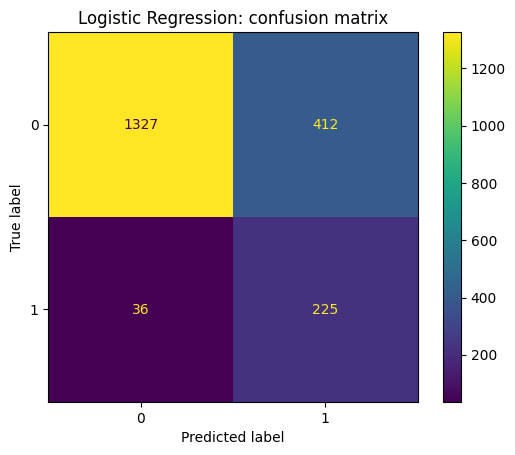

In [15]:
ConfusionMatrixDisplay.from_predictions(y_valid, logistic_pred)
plt.title("Logistic Regression: confusion matrix")
plt.show()

**Підбір параметрів:**

Експеримент із порогом видалення ознак за часткою пропущених значень показав, що найкращий результат отримано при порозі 70%: середня Balanced Accuracy становила 0.7977 ± 0.0118. Більш агресивне видалення ознак при порогах 20–50% погіршувало результат, що свідчить про наявність корисної інформації навіть в ознаках зі значною кількістю пропусків. Водночас збереження майже всіх ознак при порозі 100% знизило Balanced Accuracy до 0.7804, що може бути пов'язано з додаванням шумових або малоінформативних ознак. Тому для подальших експериментів обрано поріг 70%.

Оптимізація параметрів регуляризації Logistic Regression дозволила підвищити середню Balanced Accuracy з 0.7780 до 0.7855. Найкращою комбінацією виявилися C=3 та L1-регуляризація. Подальше збільшення C до 10 не покращило результат, хоча training score залишався високим, що може свідчити про початок перенавчання. L1-регуляризація також потенційно виконує додатковий відбір ознак через обнулення частини коефіцієнтів. Тому модель C=3, penalty='l1' обрана як новий основний кандидат для подальшої оптимізації ваг класів та порогу класифікації.

Оптимізація порогу класифікації показала максимальну Balanced Accuracy 0.7865 при threshold=0.43, порівняно з 0.7855 при стандартному порозі 0.50. Зниження порогу збільшило recall міноритарного класу 1 з 0.8414 до 0.8897, одночасно зменшивши recall класу 0 з 0.7296 до 0.6834. Оскільки приріст Balanced Accuracy становить лише близько 0.001, оптимізація threshold не дала суттєвого покращення загальної якості моделі. Водночас вона продемонструвала можливість керувати компромісом між чутливістю до двох класів.

Порівняння різних значень cardinality_threshold показало, що найкращі результати отримано при cardinality_threshold = 50. Цей варіант забезпечив найвищий середній показник Balanced Accuracy за результатами 5-fold крос-валідації (0.8041) та найкращий результат на валідаційній вибірці (0.8126). Зменшення порогу до 20 або 10 призвело до незначного погіршення якості моделі, що свідчить про втрату корисної інформації під час кодування категоріальних ознак. Використання One-Hot Encoding для ознак із кількістю категорій до 50 та Target Encoding для ознак із більшою кардинальністю виявилося найбільш ефективним підходом. Отже, для подальших експериментів і порівняння моделей доцільно використовувати саме Hybrid Encoding із cardinality_threshold = 50 як базову конфігурацію.

### Висновок щодо Logistic Regression

Підібрані параметри `C=3`, `penalty="l1"` і `class_weight="balanced"` забезпечують хороший базовий результат. L1-регуляризація додатково виконує відбір ознак через обнулення частини коефіцієнтів.

## 10. Крос-валідація і порівняння моделей

In [16]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

results = []

def evaluate_model(name, model, X, y, cv):
    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="balanced_accuracy",
        n_jobs=-1
    )

    results.append({
        "model": name,
        "mean_balanced_accuracy": scores.mean(),
        "std": scores.std()
    })

    print(name)
    print("Scores:", np.round(scores, 4))
    print(f"Mean: {scores.mean():.4f}")
    print(f"STD: {scores.std():.4f}")

In [17]:
svd_model = Pipeline([
    ("preprocessor", preprocessor),
    ("svd", TruncatedSVD(n_components=200, random_state=RANDOM_STATE)),
    ("classifier", LogisticRegression(
        C=3,
        penalty="l2",
        solver="liblinear",
        class_weight="balanced",
        max_iter=3000,
        random_state=RANDOM_STATE
    ))
])

pca_model = Pipeline([
    ("preprocessor", preprocessor),
    ("scale_all", StandardScaler()),
    ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),
    ("classifier", LogisticRegression(
        C=3,
        penalty="l2",
        solver="liblinear",
        class_weight="balanced",
        max_iter=3000,
        random_state=RANDOM_STATE
    ))
])

linear_svc_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LinearSVC(
        C=0.1,
        class_weight="balanced",
        max_iter=10000,
        random_state=RANDOM_STATE
    ))
])

In [18]:
evaluate_model("Logistic Regression", logistic_model, X, y, cv)
evaluate_model("SVD + Logistic Regression", svd_model, X, y, cv)
evaluate_model("PCA + Logistic Regression", pca_model, X, y, cv)
evaluate_model("LinearSVC", linear_svc_model, X, y, cv)

results_df = (
    pd.DataFrame(results)
    .sort_values("mean_balanced_accuracy", ascending=False)
    .reset_index(drop=True)
)

display(results_df)

Logistic Regression
Scores: [0.8197 0.7963 0.784  0.8285 0.7916]
Mean: 0.8040
STD: 0.0171
SVD + Logistic Regression
Scores: [0.8196 0.7913 0.7832 0.827  0.7919]
Mean: 0.8026
STD: 0.0173
PCA + Logistic Regression
Scores: [0.7965 0.8021 0.7879 0.8223 0.7936]
Mean: 0.8005
STD: 0.0119
LinearSVC
Scores: [0.8133 0.7896 0.7877 0.8266 0.7895]
Mean: 0.8013
STD: 0.0158


,model,mean_balanced_accuracy,std
0,Logistic Regression,0.804012,0.017067
1,SVD + Logistic Regression,0.802594,0.017349
2,LinearSVC,0.801327,0.015783
3,PCA + Logistic Regression,0.800486,0.011860


### Порівняння моделей

За результатами попереднього запуску:

| Модель | Середня Balanced Accuracy | STD |
|---|---:|---:|
| Logistic Regression | 0.8040 | 0.0171 |
| SVD + Logistic Regression | 0.8026 | 0.0173 |
| LinearSVC | 0.8013 | 0.0158 |
| PCA + Logistic Regression | 0.8005 | 0.0119 |

Зменшення розмірності за допомогою PCA та SVD не покращило результат. Найкращою серед лінійних моделей залишилася Logistic Regression без зменшення розмірності.

## 11. CatBoostClassifier

CatBoost природно працює з категоріальними ознаками, не потребує One-Hot Encoding та здатний моделювати нелінійні залежності. Пропуски в категоріальних колонках замінюються окремою категорією `MISSING`; числові пропуски CatBoost обробляє самостійно.

In [19]:
def prepare_catboost_data(df, categorical_features):
    prepared = df.copy()

    for column in categorical_features:
        prepared[column] = (
            prepared[column]
            .fillna("MISSING")
            .astype(str)
        )

    return prepared


cat_features = X.select_dtypes(exclude="number").columns.tolist()

X_train_cb = prepare_catboost_data(X_train, cat_features)
X_valid_cb = prepare_catboost_data(X_valid, cat_features)

In [20]:
catboost_model = CatBoostClassifier(
    iterations=305,
    learning_rate=0.05,
    depth=6,
    class_weights=[1, 8],
    l2_leaf_reg=3,
    loss_function="Logloss",
    eval_metric="BalancedAccuracy",
    random_seed=RANDOM_STATE,
    allow_writing_files=False,
    verbose=100
)

catboost_model.fit(
    X_train_cb,
    y_train,
    cat_features=cat_features
)

catboost_pred = np.asarray(
    catboost_model.predict(X_valid_cb)
).reshape(-1).astype(int)

catboost_ba = balanced_accuracy_score(y_valid, catboost_pred)

print(f"Balanced Accuracy: {catboost_ba:.4f}")
print(classification_report(y_valid, catboost_pred))

0:	learn: 0.7281406	total: 144ms	remaining: 43.7s
100:	learn: 0.8880880	total: 5.41s	remaining: 10.9s
200:	learn: 0.9149220	total: 10.7s	remaining: 5.55s
300:	learn: 0.9376095	total: 16.2s	remaining: 216ms
304:	learn: 0.9382564	total: 16.4s	remaining: 0us
Balanced Accuracy: 0.9019
              precision    recall  f1-score   support

           0       0.99      0.88      0.93      1739
           1       0.54      0.92      0.68       261

    accuracy                           0.89      2000
   macro avg       0.76      0.90      0.80      2000
weighted avg       0.93      0.89      0.90      2000



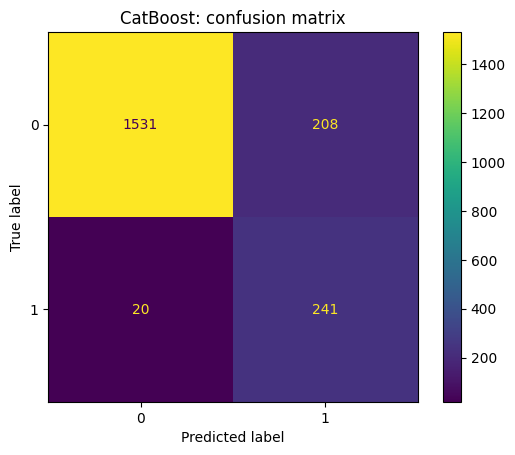

In [21]:
ConfusionMatrixDisplay.from_predictions(y_valid, catboost_pred)
plt.title("CatBoost: confusion matrix")
plt.show()

**Підбір параметрів:**

Для побудови моделі класифікації було проведено послідовний підбір основних гіперпараметрів CatBoostClassifier з використанням крос-валідації та метрики Balanced Accuracy, оскільки цільова змінна має незбалансований розподіл класів.

На першому етапі було досліджено вплив параметра class_weights. Найкращий результат показало співвідношення [1,8], яке забезпечило середнє значення Balanced Accuracy = 0.8960. Це підтвердило, що додаткове збільшення ваги міноритарного класу дозволяє покращити його розпізнавання без суттєвого погіршення загальної якості моделі.

Далі було виконано підбір глибини дерев (depth). Порівняння значень від 4 до 8 показало, що найкращу якість забезпечує depth = 6. Менші значення не дозволяли моделі повністю описати залежності між ознаками, тоді як більші значення призводили до початку перенавчання та не покращували результат.

Наступним кроком було дослідження параметра learning_rate. Було встановлено, що значення 0.05 забезпечує найкращий баланс між швидкістю навчання та здатністю моделі до узагальнення. Менше значення (0.01) призводило до недостатнього навчання моделі, а більше (0.10) не давало додаткового приросту якості.

Також було проаналізовано параметр l2_leaf_reg, який виконує роль L2-регуляризації. Найкращий результат було отримано при l2_leaf_reg = 3, тоді як сильніша регуляризація дещо знижувала якість моделі.

Після підбору гіперпараметрів модель була перевірена на відкладеній валідаційній вибірці з використанням механізму Early Stopping. Початково було задано 1000 ітерацій, однак навчання автоматично завершилося після відсутності покращення протягом 100 ітерацій. Найкращий результат було досягнуто на 304-й ітерації, після чого CatBoost автоматично скоротив модель до 305 дерев. Це свідчить про те, що подальше збільшення кількості дерев лише покращувало якість на навчальній вибірці, але вже не покращувало узагальнюючу здатність моделі.

У результаті було отримано:

середнє значення Balanced Accuracy за крос-валідацією — 0.8980; Standard Deviation = 0.0106, що свідчить про стабільність моделі на різних розбиттях даних; Balanced Accuracy = 0.9019 на незалежній валідаційній вибірці.

Різниця між результатом крос-валідації (0.8980) та валідаційної вибірки (0.9019) становить лише 0.0039, що є меншою за стандартне відхилення крос-валідації. Це підтверджує відсутність суттєвого перенавчання та хорошу здатність моделі узагальнювати нові дані.

### Результат CatBoost

Під час попереднього запуску модель показала:

- середня Balanced Accuracy за крос-валідацією — **0.8980**;
- стандартне відхилення — **0.0106**;
- Balanced Accuracy на відкладеній вибірці — **0.9019**.

Це суттєво краще за результат Logistic Regression близько 0.804. Тому CatBoost обрано як фінальну модель.

Параметри фінальної моделі:
- `class_weights=[1, 8]`;
- `depth=6`;
- `learning_rate=0.05`;
- `l2_leaf_reg=3`;
- `iterations=305`.

## 12. Навчання фінальної моделі на всіх доступних навчальних даних

In [22]:
X_full_cb = prepare_catboost_data(X, cat_features)
X_test_cb = prepare_catboost_data(competition_test_df, cat_features)

# Гарантуємо однаковий склад і порядок ознак
X_test_cb = X_test_cb.reindex(columns=X_full_cb.columns)

final_model = CatBoostClassifier(
    iterations=305,
    learning_rate=0.05,
    depth=6,
    class_weights=[1, 8],
    l2_leaf_reg=3,
    loss_function="Logloss",
    eval_metric="BalancedAccuracy",
    random_seed=RANDOM_STATE,
    allow_writing_files=False,
    verbose=100
)

final_model.fit(
    X_full_cb,
    y,
    cat_features=cat_features
)

test_predictions = np.asarray(
    final_model.predict(X_test_cb)
).reshape(-1).astype(int)

print("Кількість прогнозів:", len(test_predictions))
print("Розподіл прогнозів:")
print(pd.Series(test_predictions).value_counts().sort_index())

0:	learn: 0.7279094	total: 38.5ms	remaining: 11.7s
100:	learn: 0.8815898	total: 6.27s	remaining: 12.7s
200:	learn: 0.9147451	total: 12.7s	remaining: 6.55s
300:	learn: 0.9360572	total: 19.3s	remaining: 256ms
304:	learn: 0.9364022	total: 19.5s	remaining: 0us
Кількість прогнозів: 2500
Розподіл прогнозів:
0    1951
1     549
Name: count, dtype: int64


## 13. Формування submission

In [23]:
submission = sample_submission.copy()
submission["y"] = test_predictions

assert list(submission.columns) == ["index", "y"]
assert len(submission) == len(competition_test_df)
assert submission["y"].isin([0, 1]).all()
assert submission.isna().sum().sum() == 0

submission_path = "/kaggle/working/submission.csv"
submission.to_csv(submission_path, index=False)

display(submission.head())
print("Submission shape:", submission.shape)
print("Файл збережено:", submission_path)

,index,y
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


Submission shape: (2500, 2)
Файл збережено: /kaggle/working/submission.csv


## 14. Загальний висновок

У роботі було побудовано повний процес бінарної класифікації: від аналізу даних до формування файлу прогнозів.

Основні результати:

1. Виявлено суттєвий дисбаланс класів, тому для оцінювання використано `Balanced Accuracy`.
2. Для лінійних моделей створено конвеєр із:
   - видаленням ознак із 70% або більше пропусків;
   - медіанним заповненням числових пропусків;
   - стандартизацією;
   - One-Hot Encoding для низькокардинальних категорій;
   - Target Encoding для висококардинальних категорій.
3. PCA та SVD не покращили якість порівняно зі звичайною Logistic Regression.
4. Найкращий результат показав CatBoostClassifier, який краще враховує нелінійні залежності та категоріальні ознаки.
5. Перед створенням submission фінальну модель перенавчено на всіх 10 000 навчальних об’єктах.
6. Результат збережено у файл `submission.csv`.

Подальше покращення можливе через оптимізацію порогу класифікації, розширений підбір параметрів CatBoost, перевірку ансамблів та аналіз важливості ознак.